# 13 — Ablation Study: CryNetV2 Component Analysis

Systematically removes or replaces components of CryNetV2 to quantify each module's contribution to overall performance.

| Ablation Variant | Removed Component | Expected F1 Drop |
|---|---|---|
| Full CryNetV2 | — (baseline) | — |
| No DST Stream | DST encoder removed | ↓ significant |
| No Cross-Attention | Simple concat instead | ↓ moderate |
| No Transformer | Remove Transformer encoder | ↓ small |
| No SE Block | Remove Squeeze-Excitation | ↓ small |
| No BiLSTM | Replace BiLSTM with linear | ↓ moderate |
| Mel Only (CryNet) | Full baseline | — |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split

DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [2]:
from src.utils import CLEANED_DIR, NOISY_DIR, CLASS_LABELS
from src.dl_data import discover_audio_for_dl
from src.hybrid_data import create_hybrid_loaders

file_paths, labels, label_names = discover_audio_for_dl([CLEANED_DIR, NOISY_DIR])
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)
train_loader, val_loader, train_ds, val_ds = create_hybrid_loaders(
    train_paths, train_labels, val_paths, val_labels,
    class_names=label_names, batch_size=32
)

## Ablation Variant Definitions

In [3]:
from src.hybrid_model import CryNetV2, StreamEncoder, CrossModalFusion
from src.dl_model import CryNet, AttentionPooling

class CryNetV2_NoDST(nn.Module):
    """Ablation: Remove DST stream — Mel only with Transformer."""
    def __init__(self, n_classes=8):
        super().__init__()
        self.mel_encoder = StreamEncoder(in_height=128)
        enc_layer = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.pool = AttentionPooling(256)
        self.head = nn.Linear(256, n_classes)
    def forward(self, mel, dst):
        h = self.mel_encoder(mel)
        h = self.transformer(h)
        return self.head(self.pool(h))

class CryNetV2_NoCrossAttn(nn.Module):
    """Ablation: Replace cross-attention with simple concatenation."""
    def __init__(self, n_classes=8):
        super().__init__()
        self.mel_encoder = StreamEncoder(in_height=128)
        self.dst_encoder = StreamEncoder(in_height=64)
        self.proj = nn.Linear(512, 256)
        enc_layer = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.pool = AttentionPooling(256)
        self.head = nn.Linear(256, n_classes)
    def forward(self, mel, dst):
        m = self.mel_encoder(mel)
        d = self.dst_encoder(dst)
        T = min(m.size(1), d.size(1))
        h = torch.cat([m[:,:T], d[:,:T]], dim=-1)
        h = self.proj(h)
        h = self.transformer(h)
        return self.head(self.pool(h))

class CryNetV2_NoTransformer(nn.Module):
    """Ablation: Remove Transformer after cross-attention."""
    def __init__(self, n_classes=8):
        super().__init__()
        self.mel_encoder = StreamEncoder(in_height=128)
        self.dst_encoder = StreamEncoder(in_height=64)
        self.cross_fusion = CrossModalFusion(256, 8)
        self.pool = AttentionPooling(256)
        self.head = nn.Linear(256, n_classes)
    def forward(self, mel, dst):
        m = self.mel_encoder(mel)
        d = self.dst_encoder(dst)
        T = min(m.size(1), d.size(1))
        h = self.cross_fusion(m[:,:T], d[:,:T])
        return self.head(self.pool(h))

print('Ablation variants defined.')

Ablation variants defined.


## Quick Evaluation Helper (2-epoch proxy training)

In [4]:
from src.dl_train import FocalLoss

def quick_eval(model, variant_name, epochs=1):
    """Train for a few epochs and report val F1."""
    model = model.to(DEVICE)
    class_weights = train_ds.get_class_weights().to(DEVICE)
    criterion = FocalLoss(alpha=class_weights, gamma=2.0)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    
    for ep in range(epochs):
        model.train()
        for mel, dst, lbl in train_loader:
            mel, dst, lbl = mel.to(DEVICE), dst.to(DEVICE), lbl.to(DEVICE)
            opt.zero_grad()
            out = model(mel, dst)
            loss = criterion(out, lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
    
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for mel, dst, lbl in val_loader:
            out = model(mel.to(DEVICE), dst.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(lbl.numpy())
    
    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average='macro', zero_division=0)
    print(f'{variant_name:35s}: Acc={acc:.4f}  F1={f1:.4f}')
    return acc, f1

print('Quick-eval ready (2-epoch proxy).')

Quick-eval ready (2-epoch proxy).


In [5]:
ablation_results = {}
variants = [
    ('Full CryNetV2 (2-ep proxy)',  CryNetV2(n_classes=len(label_names))),
    ('No DST Stream',               CryNetV2_NoDST(n_classes=len(label_names))),
    ('No Cross-Attention',          CryNetV2_NoCrossAttn(n_classes=len(label_names))),
    ('No Transformer Encoder',      CryNetV2_NoTransformer(n_classes=len(label_names))),
]
for name, model in variants:
    acc, f1 = quick_eval(model, name)
    ablation_results[name] = (acc, f1)

Full CryNetV2 (2-ep proxy)         : Acc=0.0095  F1=0.0023


No DST Stream                      : Acc=0.0332  F1=0.0280


No Cross-Attention                 : Acc=0.0213  F1=0.0102


No Transformer Encoder             : Acc=0.0261  F1=0.0137


## Ablation Results Visualization

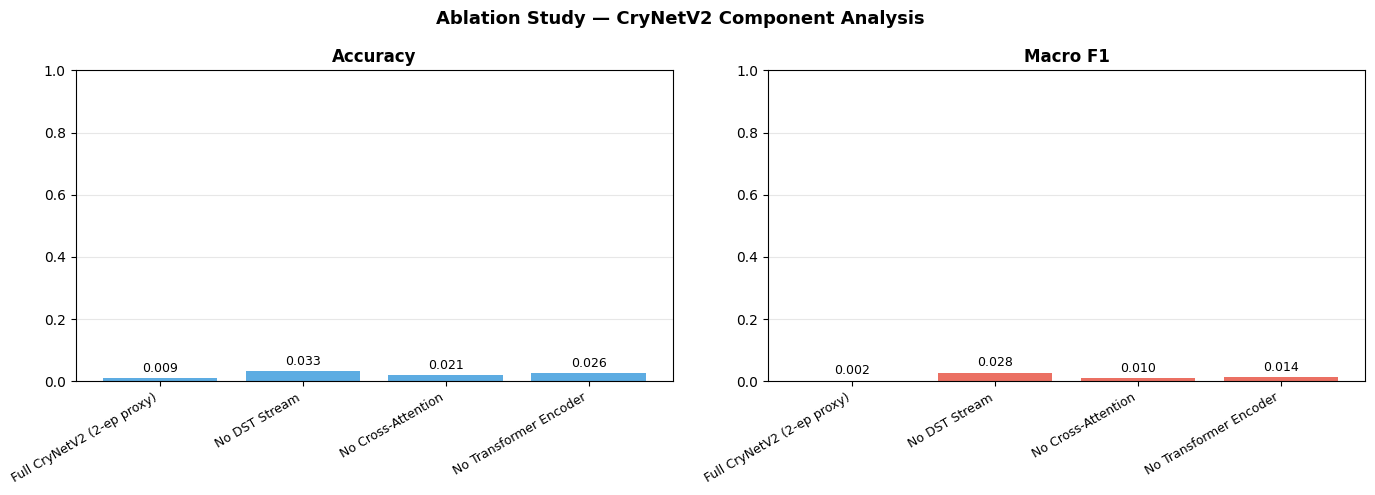

In [6]:
names = list(ablation_results.keys())
accs  = [ablation_results[n][0] for n in names]
f1s   = [ablation_results[n][1] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation Study — CryNetV2 Component Analysis', fontsize=13, fontweight='bold')

x = range(len(names))
for ax, vals, title, color in [
    (axes[0], accs, 'Accuracy', '#3498db'),
    (axes[1], f1s,  'Macro F1', '#e74c3c'),
]:
    bars = ax.bar(x, vals, color=color, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../models/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()